# Reto de la Semanan 4: Optimización con Regresión Logística

Este cuaderno implementa la solución al problema de optimización para encontrar los parámetros óptimos de un clasificador binario lineal utilizando regresión logística, basándose en el documento proporcionado y el conjunto de datos `breastCancer`.

In [2]:
#  Importamos las librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [3]:
# importamos los datos
ruta_archivo = 'BreastCancer.csv'
data = pd.read_csv(ruta_archivo)

In [4]:
# Extraemos los valores de los datos en la matriz X
X = data[['radius_mean', 'smoothness_mean']].values

# Extraemos la variable objetivo
t = data['pronostic'].values

Z = np.hstack((X, np.ones((X.shape[0], 1))))

m = Z.shape[0] # # entrenamiento
n = Z.shape[1] # # caracteristicas

print(f"\nDimensión de Z (características + intercepto): {Z.shape}")
print(f"Dimensión de t (objetivo): {t.shape}")


Dimensión de Z (características + intercepto): (469, 3)
Dimensión de t (objetivo): (469,)


In [5]:
def sigmoid(v):
    """
    funcion sigmoide.
    """
    return 1 / (1 + np.exp(-v))

In [6]:
def loss_function(w, Z, t):
    """
    funcion de perdida de la regresion logistica
    """
    y = sigmoid(Z @ w) 
    epsilon = 1e-15 
    loss = -np.mean(t * np.log(y + epsilon) + (1 - t) * np.log(1 - y + epsilon))
    return loss

In [7]:
def gradient(w, Z, t):
    """
    Gradiente de la function de perdida de la regresion logistica 
    """
    y = sigmoid(Z @ w)
    grad = (1/m) * Z.T @ (y - t) 
    return grad

In [8]:
def hessian(w, Z, t):
    """
    Hessiana de la funcion de perdida de regresion logistica.
    """
    y = sigmoid(Z @ w)
    S = np.diag(y * (1 - y))
    hess = (1/m) * Z.T @ S @ Z 
    return hess

In [11]:
initial_w = np.zeros(n)

# hayamos el w optimo con la funcion minimize
resultado = minimize(loss_function, initial_w, args=(Z, t), method='CG', jac=gradient)

# extraemos el w optino
w_optimo = resultado.x


print(f"\nResultado de la Optimización:")
print(f"Éxito: {resultado.success}")
print(f"Mensaje: {resultado.message}")
print(f"w óptimo: {w_optimo}")


Resultado de la Optimización:
Éxito: True
Mensaje: Optimization terminated successfully.
w óptimo: [5.36052956 1.64164044 0.24463664]


In [13]:
# Calculamos el valor de la función objetivo, el gradiente y la Hessiana usando los w óptimos 
loss_en_w_optimo = loss_function(optimal_w, Z, t)
gradiente_en_w_optimo = gradient(optimal_w, Z, t)
hessiana_en_w_optimo = hessian(optimal_w, Z, t)

print(f"\nPérdida con w óptimo: {loss_en_w_optimo}")
print(f"Gradiente en w óptimo: {gradiente_en_w_optimo}")
print(f"Hessiana en w óptimo:\n{hessiana_en_w_optimo}")


Pérdida con w óptimo: 0.20464127697655204
Gradiente en w óptimo: [8.30765582e-06 6.31498452e-07 1.44867554e-06]
Hessiana en w óptimo:
[[ 0.01005425 -0.01356427 -0.0103909 ]
 [-0.01356427  0.05475941  0.00994577]
 [-0.0103909   0.00994577  0.06328283]]


In [14]:
# Empezamos con w inicial en ceros 
w_inicial = np.zeros(n)

# Buscamos el w óptimo usando minimize y el método CG 
resultado = minimize(loss_function, w_inicial, args=(Z, t), method='CG', jac=gradient)

# Sacamos los valores de w encontrados 🏆
w_optimo = resultado.x

print("\nResultado de la optimización:")
print(f"¿Tuvo éxito? {resultado.success}")
print(f"Mensaje: {resultado.message}")
print(f"w óptimo: {w_optimo}")



Resultado de la optimización:
¿Tuvo éxito? True
Mensaje: Optimization terminated successfully.
w óptimo: [5.36052956 1.64164044 0.24463664]


In [16]:
# Evaluamos la función objetivo, el gradiente y la Hessiana usando el w que acabamos de optimizar 

loss_en_w_optimo    = loss_function(w_optimo, Z, t)
gradiente_en_w_optimo = gradient(w_optimo, Z, t)
hessiana_en_w_optimo  = hessian(w_optimo, Z, t)

print(f"\nPérdida en w óptimo: {loss_en_w_optimo}")
print(f"Gradiente en w óptimo: {gradiente_en_w_optimo}")
print(f"Hessiana en w óptimo:\n{hessiana_en_w_optimo}")


Pérdida en w óptimo: 0.20464127697655204
Gradiente en w óptimo: [8.30765582e-06 6.31498452e-07 1.44867554e-06]
Hessiana en w óptimo:
[[ 0.01005425 -0.01356427 -0.0103909 ]
 [-0.01356427  0.05475941  0.00994577]
 [-0.0103909   0.00994577  0.06328283]]


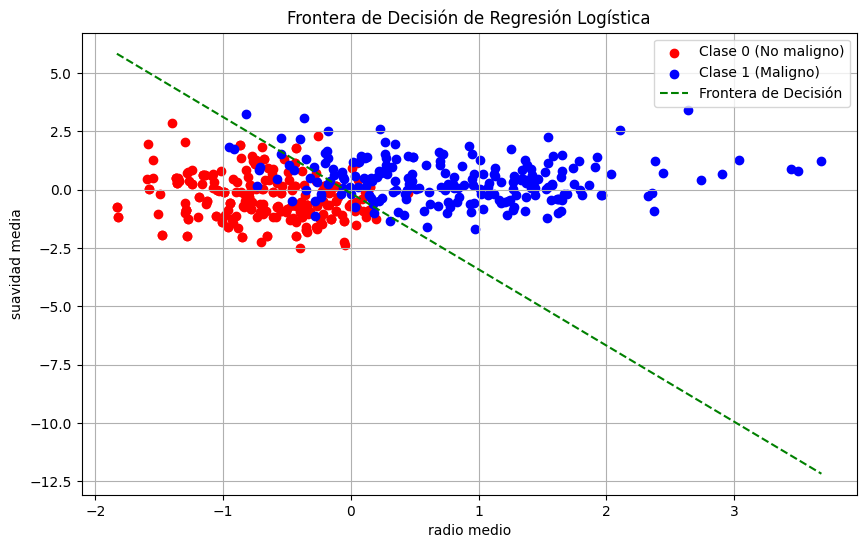

In [18]:
# Diagrama de dispersión de los datos, coloreados según la clase 
plt.figure(figsize=(10, 6))
plt.scatter(X[t == 0, 0], X[t == 0, 1], color='red', label='Clase 0 (No maligno)')
plt.scatter(X[t == 1, 0], X[t == 1, 1], color='blue', label='Clase 1 (Maligno)')

# Trazamos la línea de decisión w1*x1 + w2*x2 + w3 = 0 
# Despejamos x2: x2 = (-w1/w2)*x1 + (-w3/w2)
if w_optimo[1] != 0:
    x1_vals = np.array([X[:, 0].min(), X[:, 0].max()])
    x2_vals = (-w_optimo[0] / w_optimo[1]) * x1_vals - (w_optimo[2] / w_optimo[1])
    plt.plot(x1_vals, x2_vals, color='green', linestyle='--', label='Frontera de Decisión')

plt.xlabel('radio medio')
plt.ylabel('suavidad media')
plt.title('Frontera de Decisión de Regresión Logística')
plt.legend()
plt.grid(True)
plt.show()
